# Lab 4 — Gradient d'une surface à deux variables

## Objectifs

Dans ce notebook, nous allons :

- passer d'une dérivée scalaire à un gradient vectoriel ;
- représenter une fonction $f(x,y)$ par une surface 3D ;
- calculer manuellement une mise à jour des deux coordonnées ;
- visualiser la même trajectoire en 3D et sur des courbes de niveau ;
- observer la convergence de $x$, de $y$ et de $f(x,y)$ ;
- vérifier que plusieurs points de départ rejoignent le même minimum d'une fonction convexe.

## 1. De la courbe à la surface

Dans les labs précédents, une position était décrite par un seul nombre $x$. Nous utilisons maintenant deux coordonnées :

$$θ=(x,y).$$

La fonction associe une hauteur à chaque position du plan :

$$z=f(x,y).$$

Les coordonnées $x$ et $y$ forment l'espace dans lequel l'algorithme se déplace. La valeur $z$ représente la hauteur de la fonction.

## 2. Fonction étudiée

Nous utilisons la fonction convexe :

$$f(x,y)=(x-2)^2+2(y+1)^2+1.$$

Ses dérivées partielles sont :

$$∂f/∂x=2(x-2),$$

$$∂f/∂y=4(y+1).$$

Le gradient rassemble ces deux pentes dans un vecteur :

$$∇f(x,y)=(2(x-2), 4(y+1)).$$

Le minimum global est atteint en $(x,y)=(2,-1)$ et sa valeur est $1$.

### Que signifie une dérivée partielle ?

- $∂f/∂x$ mesure la pente lorsque $x$ change et que $y$ reste fixe ;
- $∂f/∂y$ mesure la pente lorsque $y$ change et que $x$ reste fixe.

Le gradient combine donc les deux informations pour indiquer la direction de montée la plus rapide dans le plan $(x,y)$.

## 3. Importer les bibliothèques

In [1]:
# NumPy permet de manipuler les vecteurs, les matrices et les grilles numériques.
import numpy as np

# Matplotlib permet de tracer les courbes de niveau et les graphiques 3D.
import matplotlib.pyplot as plt

# Ce style améliore la lisibilité des graphiques 2D.
plt.style.use("seaborn-v0_8-whitegrid")

## 4. Programmer la fonction et le gradient

In [2]:
def fonction(x, y):
    """Calcule f(x, y) = (x - 2)² + 2(y + 1)² + 1."""
    # Première contribution : distance horizontale à x = 2.
    terme_x = (x - 2) ** 2

    # Deuxième contribution : distance verticale à y = -1, multipliée par 2.
    terme_y = 2 * (y + 1) ** 2

    # La constante 1 fixe la hauteur minimale de la surface.
    return terme_x + terme_y + 1


def gradient(x, y):
    """Retourne le vecteur gradient [∂f/∂x, ∂f/∂y]."""
    # Pente obtenue en faisant varier x uniquement.
    pente_x = 2 * (x - 2)

    # Pente obtenue en faisant varier y uniquement.
    pente_y = 4 * (y + 1)

    # Les deux composantes sont regroupées dans un tableau NumPy.
    return np.array([pente_x, pente_y])

## 5. Construire et visualiser la surface 3D

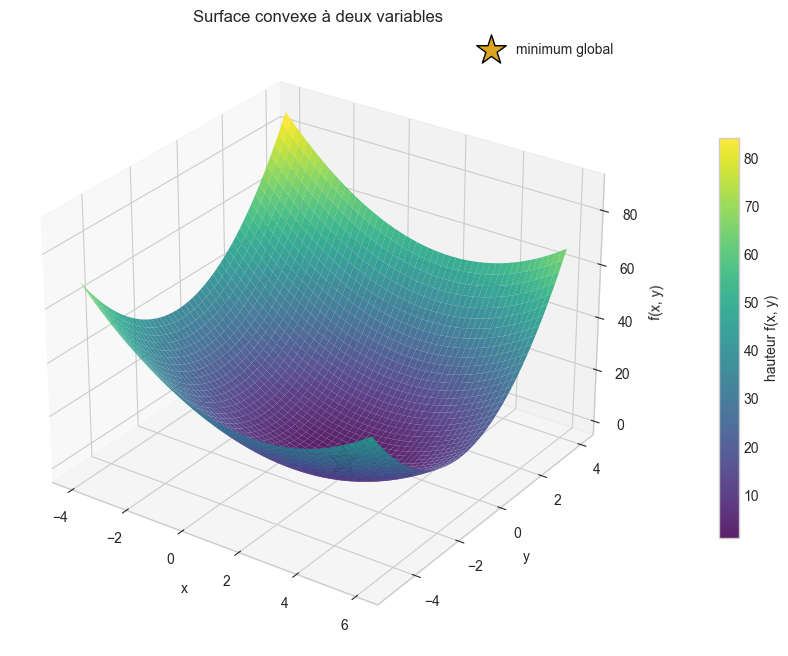

In [9]:
# Valeurs utilisées sur l'axe x.
valeurs_x = np.linspace(-4, 6, 1000)

# Valeurs utilisées sur l'axe y.
valeurs_y = np.linspace(-5, 4, 1000)

# meshgrid construit toutes les combinaisons possibles entre les x et les y.
X, Y = np.meshgrid(valeurs_x, valeurs_y)

# Calcul de la hauteur de la surface pour chaque couple (x, y).
Z = fonction(X, Y)

# Création d'une figure utilisant une projection tridimensionnelle.
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Tracé de la surface. Le dégradé de couleur encode également la hauteur.
surface = ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.88, linewidth=0)

# Une étoile indique le minimum global.
ax.scatter(2, -1, 1, marker="*", s=500, color="goldenrod", edgecolor="black", depthshade=False, label="minimum global")

# Noms des trois axes.
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")
ax.set_title("Surface convexe à deux variables")
ax.view_init(elev=28, azim=-55)
ax.legend(loc="upper right")
fig.colorbar(surface, ax=ax, shrink=0.65, pad=0.1, label="hauteur f(x, y)")
plt.show()

La surface ressemble à un bol allongé. Elle est plus courbée dans la direction $y$ à cause du coefficient $2$ placé devant $(y+1)^2$. Cette différence de courbure produira des vitesses de convergence différentes pour $x$ et $y$.

## 6. Lire le gradient dans le plan

Une carte de courbes de niveau représente la même surface vue du dessus. Chaque courbe relie des positions ayant exactement la même hauteur. Le gradient est perpendiculaire aux courbes de niveau.

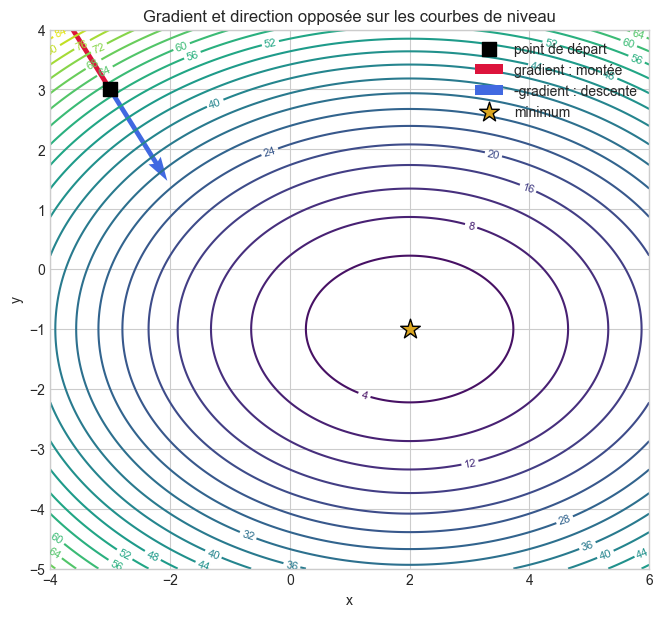

In [10]:
# Point auquel nous voulons observer le gradient.
point_depart = np.array([-3.0, 3.0])

# Calcul du vecteur gradient à ce point.
gradient_depart = gradient(point_depart[0], point_depart[1])

# Normalisation : seule la direction est conservée pour tracer des flèches lisibles.
direction_montee = gradient_depart / np.linalg.norm(gradient_depart)
direction_descente = -direction_montee

# Création du graphique vu du dessus.
fig, ax = plt.subplots(figsize=(10, 7))

# Les courbes de niveau sont calculées à partir de la même grille X, Y, Z.
courbes = ax.contour(X, Y, Z, levels=22, cmap="viridis")
ax.clabel(courbes, inline=True, fontsize=8)

# Affichage du point de départ.
ax.scatter(*point_depart, marker="s", s=100, color="black", zorder=6, label="point de départ")

# Flèche du gradient : direction de montée la plus rapide.
ax.quiver(
    point_depart[0], point_depart[1],
    1.8 * direction_montee[0], 1.8 * direction_montee[1],
    angles="xy", scale_units="xy", scale=1, color="crimson", width=0.008, label="gradient : montée",
)

# Flèche opposée : direction utilisée par la descente de gradient.
ax.quiver(
    point_depart[0], point_depart[1],
    1.8 * direction_descente[0], 1.8 * direction_descente[1],
    angles="xy", scale_units="xy", scale=1, color="royalblue", width=0.008, label="-gradient : descente",
)

# Position du minimum dans le plan.
ax.scatter(2, -1, marker="*", s=220, color="goldenrod", edgecolor="black", zorder=7, label="minimum")

ax.set_title("Gradient et direction opposée sur les courbes de niveau")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper right")
plt.show()

## 7. Calculer manuellement une mise à jour

La règle vectorielle est :

$$θ_{nouveau}=θ_{actuel}-α∇f(θ_{actuel}).$$

Nous partons de $(-3,3)$ et choisissons $α=0.1$. Le gradient vaut :

$$∇f(-3,3)=(-10,16).$$

Les deux coordonnées sont mises à jour simultanément.

In [11]:
# Taux d'apprentissage commun aux deux coordonnées.
taux = 0.1

# Valeur de la fonction avant la mise à jour.
valeur_depart = fonction(point_depart[0], point_depart[1])

# Le déplacement est le gradient multiplié par -alpha.
deplacement = -taux * gradient_depart

# Addition vectorielle entre le point actuel et le déplacement.
point_nouveau = point_depart + deplacement

# Valeur de la fonction après la mise à jour.
valeur_nouvelle = fonction(point_nouveau[0], point_nouveau[1])

print("Point de départ :", point_depart)
print("Gradient        :", gradient_depart)
print("Déplacement     :", deplacement)
print("Nouveau point   :", point_nouveau)
print(f"Valeur avant   : {valeur_depart:.2f}")
print(f"Valeur après   : {valeur_nouvelle:.2f}")

Point de départ : [-3.  3.]
Gradient        : [-10.  16.]
Déplacement     : [ 1.  -1.6]
Nouveau point   : [-2.   1.4]
Valeur avant   : 58.00
Valeur après   : 28.52


Le résultat est :

$$(-3,3)-0.1(-10,16)=(-2,1.4).$$

La valeur de la fonction passe de $58$ à $28.52$. Une seule mise à jour modifie donc simultanément $x$, $y$ et la hauteur sur la surface.

## 8. Programmer plusieurs mises à jour

In [12]:
def descente_gradient_2d(gradient_f, point_depart, taux, nombre_iterations):
    """Retourne toutes les positions [x, y] visitées."""

    # Conversion du point initial en tableau décimal indépendant.
    point = np.array(point_depart, dtype=float)

    # copy() évite que les anciennes positions changent lorsque point est mis à jour.
    historique = [point.copy()]

    # Répétition de la mise à jour vectorielle.
    for _ in range(nombre_iterations):
        # Calcul des deux composantes du gradient.
        vecteur_gradient = gradient_f(point[0], point[1])

        # Mise à jour simultanée de x et de y.
        point = point - taux * vecteur_gradient

        # Conservation d'une copie de la nouvelle position.
        historique.append(point.copy())

    # Chaque ligne du tableau final contient une position [x, y].
    return np.array(historique)

In [13]:
# Exécution de trente mises à jour depuis (-3, 3).
trajectoire = descente_gradient_2d(
    gradient_f=gradient,
    point_depart=(-3, 3),
    taux=0.1,
    nombre_iterations=30,
)

# Séparation des colonnes x et y pour faciliter les graphiques.
trajet_x = trajectoire[:, 0]
trajet_y = trajectoire[:, 1]

# Calcul de la hauteur associée à chaque position.
trajet_z = fonction(trajet_x, trajet_y)

# Affichage des six premières positions.
print(f"{'itération':>10} | {'x':>10} | {'y':>10} | {'f(x,y)':>10}")
print("-" * 49)
for iteration in range(6):
    print(f"{iteration:10d} | {trajet_x[iteration]:10.4f} | {trajet_y[iteration]:10.4f} | {trajet_z[iteration]:10.4f}")

print("\nPosition finale :", np.round(trajectoire[-1], 6))
print(f"Valeur finale   : {trajet_z[-1]:.8f}")

 itération |          x |          y |     f(x,y)
-------------------------------------------------
         0 |    -3.0000 |     3.0000 |    58.0000
         1 |    -2.0000 |     1.4000 |    28.5200
         2 |    -1.2000 |     0.4400 |    15.3872
         3 |    -0.5600 |    -0.1360 |     9.0466
         4 |    -0.0480 |    -0.4816 |     5.7318
         5 |     0.3616 |    -0.6890 |     3.8778

Position finale : [ 1.99381  -0.999999]
Valeur finale   : 1.00003831


## 9. Visualiser la trajectoire sur la surface 3D

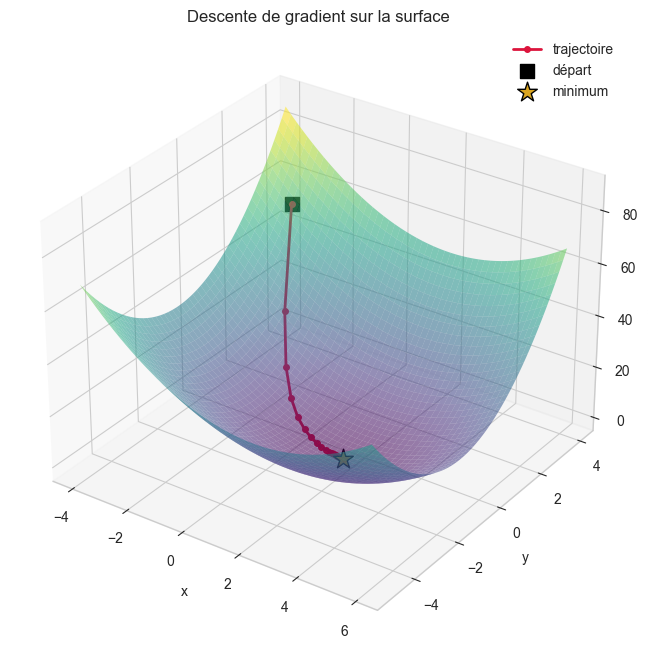

In [14]:
# Création d'une nouvelle scène 3D.
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Surface rendue légèrement transparente pour rendre le trajet visible.
ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.55, linewidth=0)

# Ligne rouge reliant les positions successives de l'algorithme.
ax.plot(trajet_x, trajet_y, trajet_z, "o-", color="crimson", markersize=4, linewidth=2, label="trajectoire")

# Carré noir pour le départ et étoile dorée pour le minimum.
ax.scatter(trajet_x[0], trajet_y[0], trajet_z[0], marker="s", s=90, color="black", label="départ")
ax.scatter(2, -1, 1, marker="*", s=220, color="goldenrod", edgecolor="black", depthshade=False, label="minimum")

ax.set_title("Descente de gradient sur la surface")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")
ax.view_init(elev=30, azim=-55)
ax.legend()
plt.show()

## 10. Visualiser la même trajectoire vue du dessus

La vue 3D montre la diminution de la hauteur. La vue par courbes de niveau montre plus clairement les directions prises dans le plan $(x,y)$.

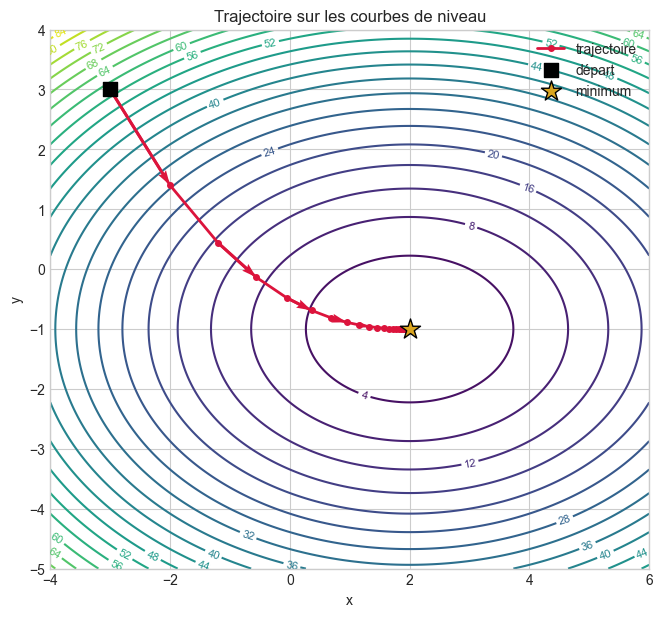

In [15]:
# Création de la carte de niveau.
fig, ax = plt.subplots(figsize=(10, 7))
niveaux = ax.contour(X, Y, Z, levels=24, cmap="viridis")
ax.clabel(niveaux, inline=True, fontsize=8)

# Tracé de la trajectoire dans le plan des paramètres.
ax.plot(trajet_x, trajet_y, "o-", color="crimson", markersize=4, linewidth=2, label="trajectoire")

# Marquage du départ et du minimum.
ax.scatter(trajet_x[0], trajet_y[0], marker="s", s=100, color="black", zorder=6, label="départ")
ax.scatter(2, -1, marker="*", s=230, color="goldenrod", edgecolor="black", zorder=7, label="minimum")

# Quelques flèches rendent le sens du trajet explicite.
for index in range(0, min(12, len(trajectoire) - 1), 2):
    delta = trajectoire[index + 1] - trajectoire[index]
    ax.quiver(
        trajectoire[index, 0], trajectoire[index, 1],
        delta[0], delta[1],
        angles="xy", scale_units="xy", scale=1, color="crimson", width=0.005,
    )

ax.set_title("Trajectoire sur les courbes de niveau")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper right")
plt.show()

Le trajet coupe les courbes de niveau au lieu de les suivre. Cela correspond au fait que le gradient est perpendiculaire à ces courbes. La trajectoire n'est pas parfaitement droite, car les directions $x$ et $y$ n'ont pas la même courbure.

## 11. Observer séparément les convergences

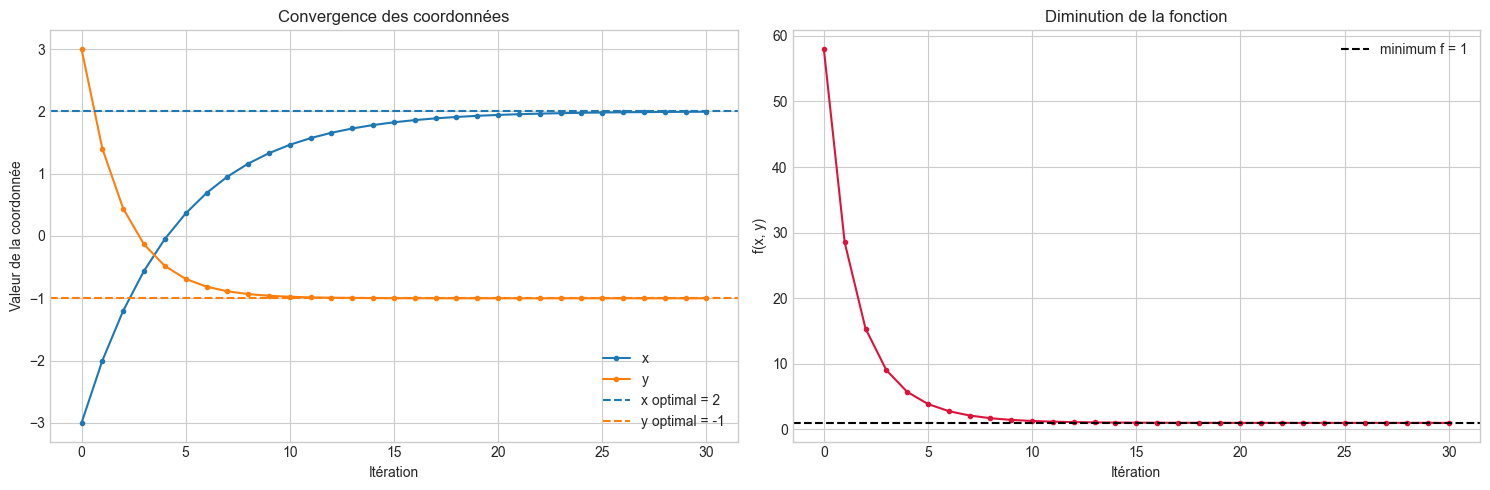

In [16]:
# Numéros des itérations, y compris l'état initial.
iterations = np.arange(len(trajectoire))

# Création de deux graphiques côte à côte.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Premier graphique : évolution indépendante de x et de y.
axes[0].plot(iterations, trajet_x, "o-", markersize=3, label="x")
axes[0].plot(iterations, trajet_y, "o-", markersize=3, label="y")
axes[0].axhline(2, linestyle="--", color="tab:blue", label="x optimal = 2")
axes[0].axhline(-1, linestyle="--", color="tab:orange", label="y optimal = -1")
axes[0].set_title("Convergence des coordonnées")
axes[0].set_xlabel("Itération")
axes[0].set_ylabel("Valeur de la coordonnée")
axes[0].legend()

# Deuxième graphique : diminution de la hauteur de la fonction.
axes[1].plot(iterations, trajet_z, "o-", color="crimson", markersize=3)
axes[1].axhline(1, linestyle="--", color="black", label="minimum f = 1")
axes[1].set_title("Diminution de la fonction")
axes[1].set_xlabel("Itération")
axes[1].set_ylabel("f(x, y)")
axes[1].legend()

plt.tight_layout()
plt.show()

La coordonnée $y$ converge plus vite parce que sa composante du gradient est multipliée par $4$, contre $2$ pour $x$. Le gradient adapte donc naturellement chaque direction à la pente locale correspondante.

## 12. Comparer plusieurs points de départ

La fonction est convexe et possède un seul minimum. Avec le taux choisi, plusieurs initialisations doivent donc rejoindre la même position.

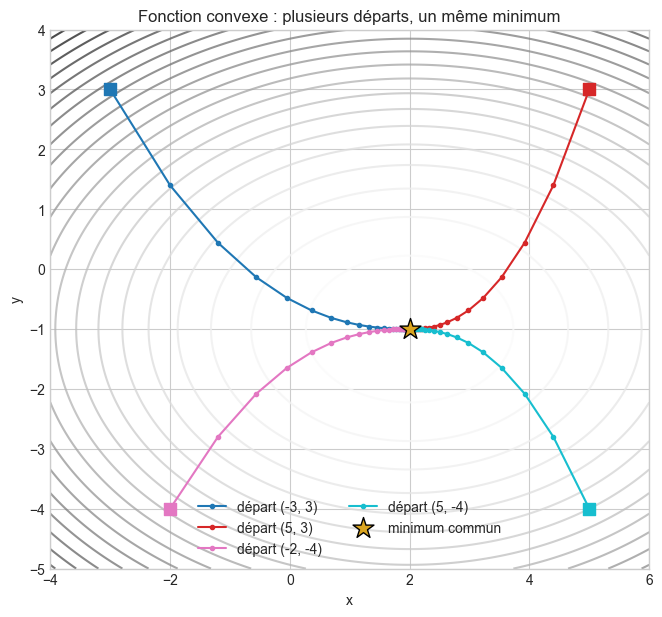

In [17]:
# Quatre points situés dans différentes régions du plan.
points_depart = [(-3, 3), (5, 3), (-2, -4), (5, -4)]

# Une couleur différente est attribuée à chaque expérience.
couleurs = plt.cm.tab10(np.linspace(0, 1, len(points_depart)))

# Création du fond constitué des courbes de niveau.
fig, ax = plt.subplots(figsize=(10, 7))
ax.contour(X, Y, Z, levels=24, cmap="Greys", alpha=0.75)

# Calcul et tracé de chaque trajectoire.
for couleur, depart in zip(couleurs, points_depart):
    trajet = descente_gradient_2d(gradient, depart, taux=0.1, nombre_iterations=30)
    ax.plot(trajet[:, 0], trajet[:, 1], "o-", markersize=3, color=couleur, label=f"départ {depart}")
    ax.scatter(depart[0], depart[1], marker="s", s=80, color=couleur, zorder=6)

# Minimum commun aux quatre trajectoires.
ax.scatter(2, -1, marker="*", s=250, color="goldenrod", edgecolor="black", zorder=7, label="minimum commun")

ax.set_title("Fonction convexe : plusieurs départs, un même minimum")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal", adjustable="box")
ax.legend(ncol=2)
plt.show()

## 13. Ce qu'il faut retenir

1. Pour une fonction de deux variables, le gradient possède deux composantes.
2. Chaque composante est une dérivée partielle.
3. Le gradient indique la montée la plus rapide dans le plan $(x,y)$.
4. La descente utilise le vecteur opposé et met à jour toutes les coordonnées simultanément.
5. Une surface 3D et une carte de courbes de niveau représentent la même fonction.
6. Le gradient est perpendiculaire aux courbes de niveau.
7. Pour cette fonction convexe, tous les points testés convergent vers l'unique minimum global.

## 14. Exercice

On choisit le point initial $(4,2)$ et le taux $α=0.1$.

1. Calcule manuellement $∂f/∂x$ au point $(4,2)$.
2. Calcule manuellement $∂f/∂y$ au même point.
3. Construis le vecteur gradient.
4. Calcule la nouvelle position après une étape.
5. Vérifie ton résultat avec Python.
6. Lance vingt itérations et représente le trajet sur les courbes de niveau.

### Bonus

Remplace le coefficient $2$ devant $(y+1)^2$ par $8$. Recalcule la composante du gradient selon $y$, puis observe comment la trajectoire change avec le même taux d'apprentissage.